# Feedback-Related Theta Analysis

This notebook analyzes **task-related theta (4-8 Hz)** oscillations in baseline runs of the tACS bandit task.

## Overview

The goal is to extract a theta reactivity metric as an individual difference measure:

1. **Theta power extraction**: Compute instantaneous theta power using Hilbert transform
2. **ERSP computation**: Normalize power relative to pre-event baseline (percent change)
3. **Individual differences**: Quantify theta reactivity using robust percentile-based metrics
4. **Test-retest reliability**: Validate stability across baseline runs
5. **Age associations**: Examine relationship between theta reactivity and age

## Key Methodological Notes

### Timestamp Alignment

The behavioral task and EEG recording run on **separate computers** without hardware synchronization (no LSL markers). We use a heuristic alignment approach:

1. Estimate when behavioral events occurred relative to EEG recording start
2. Apply sensitivity analysis to confirm individual differences are robust to ±1s alignment shifts

**Important**: Due to this limitation, we describe theta metrics as "task-related" rather than making precise timing claims about feedback-locked vs response-locked activity.

### Channel Availability

Only 3 EEG channels are available: F4, P4, P3 (indices 4, 5, 6). The stimulation channels (F3, Fp1, FCz, FT7) are blanked by NIC2 software during recording.

---
## 0. Setup and Configuration

In [71]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import signal
from scipy.stats import pearsonr, spearmanr, ttest_ind
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='loadtxt: input contained no data')

# --- Plotly configuration (consistent with other notebooks) ---
PLOTLY_TEMPLATE = 'plotly_white'
COLOR_BLUE = '#1565C0'
COLOR_GOLD = '#FFB300'
COLOR_GREEN = '#2E7D32'
COLOR_RED = '#C62828'
COLOR_GRAY = '#757575'

# --- Path configuration ---
REPO_ROOT = Path('..').resolve()
EEG_DIR = REPO_ROOT / 'data' / 'nic' / 'raw'
BEHAV_DIR = REPO_ROOT / 'data' / 'bandit'
OUTPUT_DIR = REPO_ROOT / 'derivatives' / 'eeg' / 'feedback_theta'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Subject configuration ---
SUBJECT_INFO = {
    '10886': {'counterbalance': 'B', 'earclip': False},
    '10998': {'counterbalance': 'B', 'earclip': False, 'notes': 'Missing Run 1'},
    '11773': {'counterbalance': 'B', 'earclip': False},
    '10656': {'counterbalance': 'A', 'earclip': False},
    '10951': {'counterbalance': 'A', 'earclip': False, 'notes': 'Electrode artifact Run 1'},
    '10418': {'counterbalance': 'B', 'earclip': False},
    '10636': {'counterbalance': 'B', 'earclip': True},
    '11318': {'counterbalance': 'B', 'earclip': True},
    '10369': {'counterbalance': 'B', 'earclip': True}
}

# --- EEG constants ---
FS = 500                    # Sampling rate (Hz)
EEG_CH_IDX = [4, 5, 6]      # EEG-only recording channels (F4, P4, P3)
EEG_CH_LABELS = ['F4', 'P4', 'P3']

# --- Epoch parameters ---
EPOCH_PRE = 1.0             # Seconds before event
EPOCH_POST = 1.5            # Seconds after event
BASELINE_WIN = (-0.5, -0.1) # Baseline window relative to event (seconds)

# --- Frequency band definitions ---
THETA_BAND = (4, 8)

# --- Preprocessing parameters ---
HIGHPASS_FREQ = 0.5         # High-pass filter cutoff (Hz)
ARTIFACT_THRESH_UV = 150    # Artifact rejection threshold (microvolts)

print(f'Repository root: {REPO_ROOT}')
print(f'EEG directory: {EEG_DIR}')
print(f'Behavioral directory: {BEHAV_DIR}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'Subjects: {list(SUBJECT_INFO.keys())}')

Repository root: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit
EEG directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/nic/raw
Behavioral directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/data/bandit
Output directory: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/feedback_theta
Subjects: ['10886', '10998', '11773', '10656', '10951', '10418', '10636', '11318', '10369']


---
## 1. Data Loading Utilities

In [74]:
def load_eeg_run(easy_path):
    """
    Load EEG data from a NIC2 .easy file.
    
    Returns:
        dict with keys:
            'eeg': ndarray (samples x 3), microvolts (F4, P4, P3)
            'timestamps_unix_ms': ndarray, Unix timestamps in milliseconds
            'time_sec': ndarray, time in seconds relative to recording start
            'fs': sampling rate (Hz)
    """
    raw = np.loadtxt(easy_path)
    
    # Extract EEG channels and convert nV to µV
    eeg = raw[:, EEG_CH_IDX] / 1000.0
    
    # Extract Unix timestamps (column 12, milliseconds)
    timestamps_unix_ms = raw[:, 12]
    
    # Compute relative time in seconds
    time_sec = (timestamps_unix_ms - timestamps_unix_ms[0]) / 1000.0
    
    return {
        'eeg': eeg,
        'timestamps_unix_ms': timestamps_unix_ms,
        'time_sec': time_sec,
        'fs': FS,
        'duration_sec': time_sec[-1]
    }


def load_behavioral_run(csv_path):
    """
    Load behavioral data from a trial-level CSV.
    
    The task code records timestamps at the END of each trial (after feedback and ITI).
    We work backwards to estimate feedback onset time.
    
    Returns:
        DataFrame with computed feedback times (relative to run start)
    """
    df = pd.read_csv(csv_path)
    
    # Remove missed trials (NaN rt) - these have no feedback
    df = df.dropna(subset=['rt']).copy()
    
    # Convert RT and ITI from milliseconds to seconds
    df['rt_sec'] = df['rt'] / 1000.0
    df['iti_sec'] = df['iti'] / 1000.0
    
    # Work backwards to get feedback onset time
    # timestamp = feedback_onset + FEEDBACK_DURATION + ITI
    FEEDBACK_DURATION = 1.0  # seconds
    df['feedback_time'] = df['timestamp'] - FEEDBACK_DURATION - df['iti_sec']
    
    # Zero to first trial's feedback for relative timing
    first_feedback = df['feedback_time'].iloc[0]
    df['feedback_time_relative'] = df['feedback_time'] - first_feedback
    
    # Store the first feedback time for later alignment
    df.attrs['first_feedback_in_run'] = first_feedback
    
    return df


def load_behavioral_with_response_times(csv_path):
    """
    Load behavioral data and compute BOTH response and feedback times.
    Used for response-locked vs feedback-locked disambiguation.
    """
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=['rt']).copy()
    
    df['rt_sec'] = df['rt'] / 1000.0
    df['iti_sec'] = df['iti'] / 1000.0
    df['wait_sec'] = df['wait_time'] / 1000.0
    
    FEEDBACK_DURATION = 1.0
    HIGHLIGHT_DURATION = 0.3
    
    df['feedback_time'] = df['timestamp'] - FEEDBACK_DURATION - df['iti_sec']
    df['response_time'] = df['feedback_time'] - df['wait_sec'] - HIGHLIGHT_DURATION
    
    first_response = df['response_time'].iloc[0]
    first_feedback = df['feedback_time'].iloc[0]
    
    df['response_time_relative'] = df['response_time'] - first_response
    df['feedback_time_relative'] = df['feedback_time'] - first_feedback
    
    df.attrs['first_response_in_run'] = first_response
    df.attrs['first_feedback_in_run'] = first_feedback
    df.attrs['response_to_feedback_delay'] = first_feedback - first_response
    
    return df


def get_latest_run_file(subject_dir, run_num):
    """Find the latest behavioral CSV for a given run (handles restarts)."""
    pattern = str(subject_dir / f'*run-{run_num:02d}*.csv')
    files = glob.glob(pattern)
    
    if not files:
        return None
    
    return max(files, key=os.path.getmtime)


def find_eeg_run(eeg_dir, subject_id, run_num):
    """Find the EEG .easy file for a given subject and run."""
    pattern = str(eeg_dir / f'*sub-{subject_id}_Run*{run_num}*.easy')
    files = glob.glob(pattern)
    
    matches = []
    for f in files:
        fname = os.path.basename(f)
        try:
            run_str = fname.split('Run')[1].strip().split('.')[0].strip()
            if int(run_str) == run_num:
                matches.append(f)
        except (IndexError, ValueError):
            continue
    
    if not matches:
        return None
    
    return max(matches, key=os.path.getsize)


def get_subject_age(subject_id):
    """Extract age from behavioral CSV for a subject."""
    behav_dir = BEHAV_DIR / f'sub-{subject_id}'
    behav_path = get_latest_run_file(behav_dir, 1)  # Use Run 1
    if behav_path is None:
        behav_path = get_latest_run_file(behav_dir, 5)  # Try Run 5
    if behav_path is None:
        return None
    
    df = pd.read_csv(behav_path)
    if 'age' in df.columns:
        return df['age'].iloc[0]
    return None


print('Data loading utilities defined.')

Data loading utilities defined.


---
## 2. Preprocessing Functions

In [77]:
def highpass_filter(data, cutoff=HIGHPASS_FREQ, fs=FS, order=4):
    """Apply zero-phase Butterworth high-pass filter."""
    nyq = fs / 2
    b, a = signal.butter(order, cutoff / nyq, btype='high')
    
    if data.ndim == 1:
        return signal.filtfilt(b, a, data)
    else:
        return np.column_stack([signal.filtfilt(b, a, data[:, i]) 
                                for i in range(data.shape[1])])


def bandpass_filter(data, band, fs=FS, order=4):
    """Apply zero-phase Butterworth bandpass filter."""
    nyq = fs / 2
    low, high = band
    b, a = signal.butter(order, [low / nyq, high / nyq], btype='band')
    
    if data.ndim == 1:
        return signal.filtfilt(b, a, data)
    else:
        return np.column_stack([signal.filtfilt(b, a, data[:, i]) 
                                for i in range(data.shape[1])])


def avg_rereference(eeg):
    """Average re-reference across channels (for subjects without earclip)."""
    avg = np.mean(eeg, axis=1, keepdims=True)
    return eeg - avg


def detect_artifacts(eeg, threshold_uv=ARTIFACT_THRESH_UV):
    """Detect samples exceeding artifact threshold. Returns boolean mask (True = artifact)."""
    return np.any(np.abs(eeg) > threshold_uv, axis=1)


def preprocess_eeg(eeg_data, has_earclip=False):
    """
    Full preprocessing pipeline for EEG data.
    
    Steps:
        1. High-pass filter at 0.5 Hz (removes slow drifts)
        2. Average re-reference (if no earclip)
        3. Detect artifacts
    """
    eeg = eeg_data['eeg'].copy()
    
    eeg = highpass_filter(eeg, cutoff=HIGHPASS_FREQ)
    
    if not has_earclip:
        eeg = avg_rereference(eeg)
    
    artifact_mask = detect_artifacts(eeg)
    
    result = eeg_data.copy()
    result['eeg'] = eeg
    result['artifact_mask'] = artifact_mask
    result['artifact_pct'] = 100 * np.mean(artifact_mask)
    
    return result


print('Preprocessing functions defined.')

Preprocessing functions defined.


---
## 3. Timestamp Alignment

Since EEG and behavioral data are recorded on separate computers without hardware synchronization, we use a heuristic alignment approach. The behavioral task typically starts 10-30 seconds into the EEG recording.

In [80]:
def align_timestamps(eeg_data, behav_data):
    """
    Align behavioral feedback times to EEG recording time using heuristic approach.
    """
    behav_data = behav_data.copy()
    
    eeg_duration = eeg_data['duration_sec']
    behav_span = behav_data['feedback_time_relative'].max()
    
    margin_start = EPOCH_PRE + 0.5
    margin_end = EPOCH_POST + 0.5
    
    if behav_span > eeg_duration:
        raise ValueError(f'Behavioral data ({behav_span:.1f}s) exceeds EEG duration ({eeg_duration:.1f}s)')
    
    estimated_first_feedback = 20.0
    
    last_feedback_time = estimated_first_feedback + behav_span
    if last_feedback_time > eeg_duration - margin_end:
        estimated_first_feedback = eeg_duration - margin_end - behav_span
    
    if estimated_first_feedback < margin_start:
        available_slack = eeg_duration - behav_span - margin_start - margin_end
        if available_slack < 0:
            estimated_first_feedback = EPOCH_PRE + 0.1
        else:
            estimated_first_feedback = margin_start
    
    behav_data['feedback_time_eeg'] = behav_data['feedback_time_relative'] + estimated_first_feedback
    
    behav_data.attrs['estimated_first_feedback'] = estimated_first_feedback
    behav_data.attrs['offset_sec'] = estimated_first_feedback
    behav_data.attrs['behav_span'] = behav_span
    behav_data.attrs['alignment_method'] = 'heuristic'
    
    return behav_data


def align_response_timestamps(eeg_data, behav_data):
    """
    Align response times to EEG recording for response-locked analysis.
    """
    behav_data = behav_data.copy()
    
    eeg_duration = eeg_data['duration_sec']
    response_span = behav_data['response_time_relative'].max()
    feedback_span = behav_data['feedback_time_relative'].max()
    resp_to_fb_delay = behav_data.attrs.get('response_to_feedback_delay', 2.5)
    
    margin_start = EPOCH_PRE + 0.5
    margin_end = EPOCH_POST + 0.5
    total_span = feedback_span + resp_to_fb_delay
    
    estimated_first_response = 10.0
    
    if estimated_first_response + total_span > eeg_duration - margin_end:
        estimated_first_response = eeg_duration - margin_end - total_span
    
    if estimated_first_response < margin_start:
        estimated_first_response = margin_start
    
    behav_data['response_time_eeg'] = behav_data['response_time_relative'] + estimated_first_response
    behav_data['feedback_time_eeg'] = behav_data['feedback_time_relative'] + estimated_first_response + resp_to_fb_delay
    
    behav_data.attrs['estimated_first_response'] = estimated_first_response
    behav_data.attrs['response_span'] = response_span
    
    return behav_data


def validate_alignment(eeg_data, behav_data):
    """Check whether behavioral events fall within EEG recording window."""
    eeg_duration = eeg_data['duration_sec']
    feedback_times = behav_data['feedback_time_eeg'].values
    
    min_time = feedback_times.min() - EPOCH_PRE
    max_time = feedback_times.max() + EPOCH_POST
    
    within_bounds = (min_time >= 0) and (max_time <= eeg_duration)
    n_valid = np.sum((feedback_times - EPOCH_PRE >= 0) & 
                     (feedback_times + EPOCH_POST <= eeg_duration))
    
    return {
        'eeg_duration_sec': eeg_duration,
        'first_feedback_sec': feedback_times.min(),
        'last_feedback_sec': feedback_times.max(),
        'behav_span_sec': behav_data.attrs.get('behav_span', feedback_times.max() - feedback_times.min()),
        'offset_sec': behav_data.attrs.get('offset_sec', np.nan),
        'alignment_method': behav_data.attrs.get('alignment_method', 'unknown'),
        'within_bounds': within_bounds,
        'n_trials': len(feedback_times),
        'n_valid_epochs': n_valid
    }


print('Timestamp alignment functions defined.')

Timestamp alignment functions defined.


---
## 4. Epoching Functions

In [83]:
def extract_epochs(eeg_data, event_times, pre_sec=EPOCH_PRE, post_sec=EPOCH_POST, 
                   reject_artifacts=True):
    """
    Extract epochs time-locked to events.
    """
    eeg = eeg_data['eeg']
    fs = eeg_data['fs']
    artifact_mask = eeg_data.get('artifact_mask', np.zeros(len(eeg), dtype=bool))
    
    n_pre = int(pre_sec * fs)
    n_post = int(post_sec * fs)
    n_samples = n_pre + n_post
    n_channels = eeg.shape[1]
    
    times = np.linspace(-pre_sec, post_sec, n_samples, endpoint=False)
    
    epochs = []
    valid_idx = []
    reject_idx = []
    
    for i, t in enumerate(event_times):
        center_sample = int(t * fs)
        start_sample = center_sample - n_pre
        end_sample = center_sample + n_post
        
        if start_sample < 0 or end_sample > len(eeg):
            reject_idx.append(i)
            continue
        
        segment = eeg[start_sample:end_sample, :]
        
        if reject_artifacts and np.any(artifact_mask[start_sample:end_sample]):
            reject_idx.append(i)
            continue
        
        epochs.append(segment)
        valid_idx.append(i)
    
    if len(epochs) == 0:
        return {
            'epochs': np.zeros((0, n_samples, n_channels)),
            'times': times,
            'valid_idx': np.array([], dtype=int),
            'reject_idx': np.array(reject_idx, dtype=int),
            'n_valid': 0,
            'n_rejected': len(reject_idx)
        }
    
    return {
        'epochs': np.stack(epochs, axis=0),
        'times': times,
        'valid_idx': np.array(valid_idx, dtype=int),
        'reject_idx': np.array(reject_idx, dtype=int),
        'n_valid': len(epochs),
        'n_rejected': len(reject_idx)
    }


print('Epoching functions defined.')

Epoching functions defined.


---
## 5. Theta Power Analysis

In [86]:
def compute_band_power_timecourse(epochs, times, band=THETA_BAND, fs=FS):
    """
    Compute instantaneous band power for each epoch using Hilbert transform.
    """
    n_epochs, n_samples, n_channels = epochs.shape
    power = np.zeros_like(epochs)
    
    for ch in range(n_channels):
        for ep in range(n_epochs):
            filtered = bandpass_filter(epochs[ep, :, ch], band, fs)
            analytic = signal.hilbert(filtered)
            envelope = np.abs(analytic)
            power[ep, :, ch] = envelope ** 2
    
    return power


def compute_ersp(epochs, times, band=THETA_BAND, baseline_win=BASELINE_WIN, fs=FS):
    """
    Compute Event-Related Spectral Perturbation (ERSP).
    ERSP = (power - baseline_power) / baseline_power * 100
    """
    power = compute_band_power_timecourse(epochs, times, band, fs)
    
    baseline_mask = (times >= baseline_win[0]) & (times < baseline_win[1])
    baseline_power = power[:, baseline_mask, :].mean(axis=1, keepdims=True)
    baseline_power = np.maximum(baseline_power, 1e-10)
    
    ersp_epochs = (power - baseline_power) / baseline_power * 100
    ersp = ersp_epochs.mean(axis=0)
    
    return {
        'ersp': ersp,
        'power': power,
        'times': times
    }


print('Theta power analysis functions defined.')

Theta power analysis functions defined.


---
## 6. Single-Subject Analysis Pipeline

In [89]:
def analyze_subject_run(subject_id, run_num, verbose=True):
    """
    Full analysis pipeline for a single subject and run.
    """
    if verbose:
        print(f'\n--- Sub-{subject_id}, Run {run_num} ---')
    
    sub_info = SUBJECT_INFO.get(subject_id, {})
    has_earclip = sub_info.get('earclip', False)
    
    # --- Load EEG ---
    eeg_path = find_eeg_run(EEG_DIR, subject_id, run_num)
    if eeg_path is None:
        if verbose:
            print(f'  EEG file not found')
        return None
    
    eeg_data = load_eeg_run(eeg_path)
    if verbose:
        print(f'  EEG loaded: {eeg_data["duration_sec"]:.1f}s')
    
    # --- Load behavioral ---
    behav_dir = BEHAV_DIR / f'sub-{subject_id}'
    behav_path = get_latest_run_file(behav_dir, run_num)
    if behav_path is None:
        if verbose:
            print(f'  Behavioral file not found')
        return None
    
    behav_data = load_behavioral_run(behav_path)
    if verbose:
        print(f'  Behavioral loaded: {len(behav_data)} trials')
    
    # --- Preprocess EEG ---
    eeg_data = preprocess_eeg(eeg_data, has_earclip=has_earclip)
    if verbose:
        print(f'  Artifacts: {eeg_data["artifact_pct"]:.1f}%')
    
    # --- Align timestamps ---
    behav_data = align_timestamps(eeg_data, behav_data)
    
    # --- Validate alignment ---
    alignment = validate_alignment(eeg_data, behav_data)
    if verbose:
        print(f'  Alignment method: {alignment["alignment_method"]}')
        print(f'  Behavioral span: {alignment["behav_span_sec"]:.1f}s, EEG duration: {alignment["eeg_duration_sec"]:.1f}s')
        print(f'  Estimated offset: {alignment["offset_sec"]:.1f}s (first feedback in EEG time)')
        print(f'  Feedback range: {alignment["first_feedback_sec"]:.1f}s - {alignment["last_feedback_sec"]:.1f}s')
        print(f'  Within bounds: {alignment["within_bounds"]}')
    
    if not alignment['within_bounds']:
        if verbose:
            print('  WARNING: Events outside EEG recording window!')
        return None
    
    # --- Extract epochs ---
    feedback_times = behav_data['feedback_time_eeg'].values
    epoch_result = extract_epochs(eeg_data, feedback_times)
    
    if epoch_result['n_valid'] == 0:
        if verbose:
            print('  No valid epochs!')
        return None
    
    if verbose:
        print(f'  Epochs: {epoch_result["n_valid"]} valid, {epoch_result["n_rejected"]} rejected')
    
    # --- Compute theta ERSP ---
    epochs = epoch_result['epochs']
    times = epoch_result['times']
    valid_idx = epoch_result['valid_idx']
    
    ersp_result = compute_ersp(epochs, times, band=THETA_BAND)
    
    # --- Split by reward/no-reward ---
    reward_col = behav_data.iloc[valid_idx]['reward']
    if reward_col.dtype == bool:
        reward_mask = reward_col.values
    else:
        reward_mask = reward_col.astype(str).str.upper() == 'TRUE'
        reward_mask = reward_mask.values
    
    n_reward = reward_mask.sum()
    n_no_reward = (~reward_mask).sum()
    
    ersp_reward = None
    ersp_no_reward = None
    
    if n_reward > 0:
        reward_epochs = epochs[reward_mask]
        ersp_reward = compute_ersp(reward_epochs, times, band=THETA_BAND)['ersp']
    
    if n_no_reward > 0:
        no_reward_epochs = epochs[~reward_mask]
        ersp_no_reward = compute_ersp(no_reward_epochs, times, band=THETA_BAND)['ersp']
    
    if verbose:
        print(f'  Reward trials: {n_reward}, No-reward trials: {n_no_reward}')
    
    # Get age
    age = None
    if 'age' in behav_data.columns:
        age = behav_data['age'].iloc[0]
    
    return {
        'subject_id': subject_id,
        'run_num': run_num,
        'has_earclip': has_earclip,
        'age': age,
        'n_trials': len(behav_data),
        'n_valid_epochs': epoch_result['n_valid'],
        'n_rejected': epoch_result['n_rejected'],
        'n_reward': n_reward,
        'n_no_reward': n_no_reward,
        'times': times,
        'ersp_all': ersp_result['ersp'],
        'ersp_reward': ersp_reward,
        'ersp_no_reward': ersp_no_reward,
        'alignment': alignment,
        'artifact_pct': eeg_data['artifact_pct']
    }


print('Single-subject pipeline defined.')

Single-subject pipeline defined.


---
## 7. Run All Baseline Runs

Baseline runs are Run 1 and Run 5 (before stimulation blocks in both counterbalance orders).

In [92]:
# Analyze baseline runs (1 and 5) for all subjects
baseline_runs = [1, 5]

all_results = []

for subject_id in SUBJECT_INFO.keys():
    for run_num in baseline_runs:
        result = analyze_subject_run(subject_id, run_num, verbose=True)
        
        if result:
            all_results.append(result)

print(f'\n=== Summary ===')
print(f'Successfully analyzed: {len(all_results)} runs')
print(f'Subjects with data: {len(set(r["subject_id"] for r in all_results))}')


--- Sub-10886, Run 1 ---
  EEG loaded: 361.4s
  Behavioral loaded: 70 trials
  Artifacts: 0.2%
  Alignment method: heuristic
  Behavioral span: 349.3s, EEG duration: 361.4s
  Estimated offset: 10.1s (first feedback in EEG time)
  Feedback range: 10.1s - 359.4s
  Within bounds: True
  Epochs: 70 valid, 0 rejected
  Reward trials: 43, No-reward trials: 27

--- Sub-10886, Run 5 ---
  EEG loaded: 361.7s
  Behavioral loaded: 75 trials
  Artifacts: 0.7%
  Alignment method: heuristic
  Behavioral span: 356.7s, EEG duration: 361.7s
  Estimated offset: 3.0s (first feedback in EEG time)
  Feedback range: 3.0s - 359.7s
  Within bounds: True
  Epochs: 74 valid, 1 rejected
  Reward trials: 51, No-reward trials: 23

--- Sub-10998, Run 1 ---
  EEG file not found

--- Sub-10998, Run 5 ---
  EEG loaded: 361.5s
  Behavioral loaded: 77 trials
  Artifacts: 0.3%
  Alignment method: heuristic
  Behavioral span: 356.0s, EEG duration: 361.5s
  Estimated offset: 3.5s (first feedback in EEG time)
  Feedback ra

---
## 8. Group Average Visualization

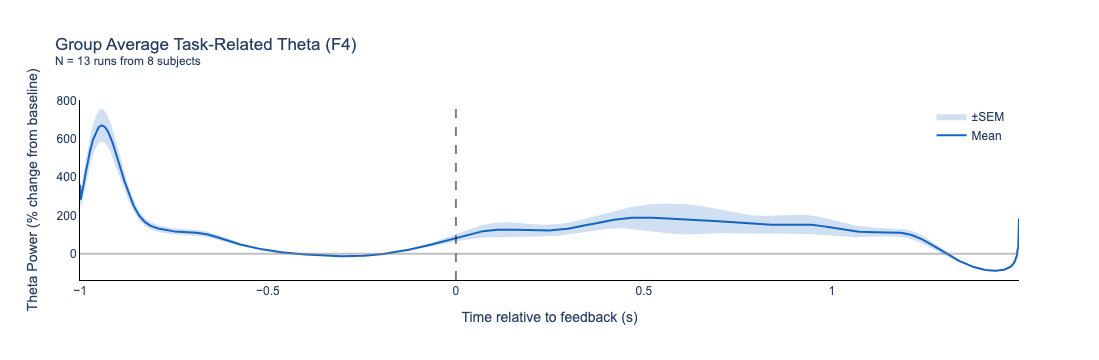

Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/feedback_theta/theta_ersp_group_average_F4.html


In [94]:
def plot_group_ersp(results, channel_idx=0):
    """
    Plot group-average task-related theta ERSP using Plotly.
    """
    if len(results) == 0:
        print('No results to plot')
        return None
    
    ch_label = EEG_CH_LABELS[channel_idx]
    times = results[0]['times']
    
    all_ersp = np.stack([r['ersp_all'][:, channel_idx] for r in results])
    mean_ersp = all_ersp.mean(axis=0)
    sem_ersp = all_ersp.std(axis=0) / np.sqrt(len(results))
    
    fig = go.Figure()
    
    # SEM band
    fig.add_trace(go.Scatter(
        x=np.concatenate([times, times[::-1]]),
        y=np.concatenate([mean_ersp + sem_ersp, (mean_ersp - sem_ersp)[::-1]]),
        fill='toself',
        fillcolor='rgba(21, 101, 192, 0.2)',
        line=dict(color='rgba(255,255,255,0)'),
        name='±SEM',
        showlegend=True
    ))
    
    # Mean line
    fig.add_trace(go.Scatter(
        x=times,
        y=mean_ersp,
        mode='lines',
        name='Mean',
        line=dict(color=COLOR_BLUE, width=2)
    ))
    
    fig.add_vline(x=0, line_dash='dash', line_color='black', opacity=0.5)
    fig.add_hline(y=0, line_color='gray', opacity=0.5)
    
    n_subjects = len(set(r['subject_id'] for r in results))
    fig.update_layout(
        title=f'Group Average Task-Related Theta ({ch_label})<br><sup>N = {len(results)} runs from {n_subjects} subjects</sup>',
        xaxis_title='Time relative to feedback (s)',
        yaxis_title='Theta Power (% change from baseline)',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        showlegend=True,
        legend=dict(yanchor='top', y=0.99, xanchor='right', x=0.99)
    )
    
    fig.update_xaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig


# Plot group average for F4
if all_results:
    fig_group = plot_group_ersp(all_results, channel_idx=0)
    if fig_group:
        fig_group.write_html(OUTPUT_DIR / 'theta_ersp_group_average_F4.html')
        print(f"Saved: {OUTPUT_DIR / 'theta_ersp_group_average_F4.html'}")

### Reward vs No-Reward Comparison

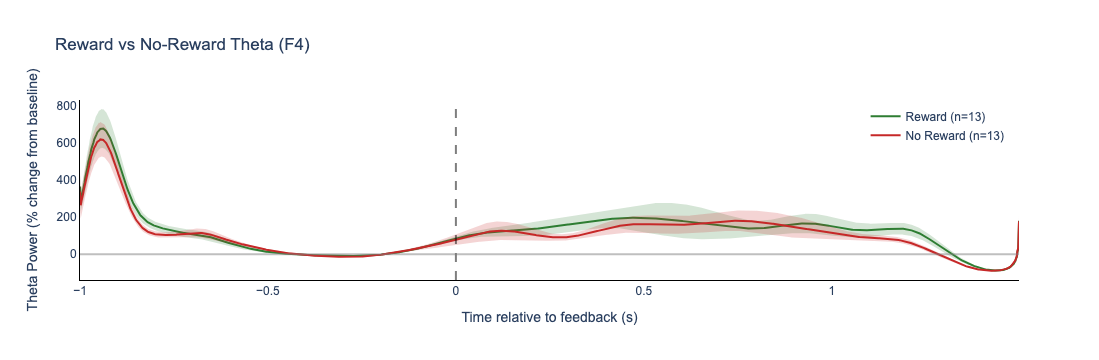

Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/feedback_theta/theta_ersp_reward_vs_noreward_F4.html


In [96]:
def plot_reward_comparison(results, channel_idx=0):
    """
    Plot group-average theta ERSP split by reward outcome.
    """
    if len(results) == 0:
        print('No results to plot')
        return None
    
    ch_label = EEG_CH_LABELS[channel_idx]
    times = results[0]['times']
    
    # Collect reward and no-reward ERSPs
    reward_ersps = [r['ersp_reward'][:, channel_idx] for r in results if r['ersp_reward'] is not None]
    no_reward_ersps = [r['ersp_no_reward'][:, channel_idx] for r in results if r['ersp_no_reward'] is not None]
    
    fig = go.Figure()
    
    if reward_ersps:
        reward_mean = np.stack(reward_ersps).mean(axis=0)
        reward_sem = np.stack(reward_ersps).std(axis=0) / np.sqrt(len(reward_ersps))
        
        fig.add_trace(go.Scatter(
            x=np.concatenate([times, times[::-1]]),
            y=np.concatenate([reward_mean + reward_sem, (reward_mean - reward_sem)[::-1]]),
            fill='toself', fillcolor='rgba(46, 125, 50, 0.2)',
            line=dict(color='rgba(255,255,255,0)'), showlegend=False
        ))
        fig.add_trace(go.Scatter(
            x=times, y=reward_mean, mode='lines',
            name=f'Reward (n={len(reward_ersps)})',
            line=dict(color=COLOR_GREEN, width=2)
        ))
    
    if no_reward_ersps:
        no_reward_mean = np.stack(no_reward_ersps).mean(axis=0)
        no_reward_sem = np.stack(no_reward_ersps).std(axis=0) / np.sqrt(len(no_reward_ersps))
        
        fig.add_trace(go.Scatter(
            x=np.concatenate([times, times[::-1]]),
            y=np.concatenate([no_reward_mean + no_reward_sem, (no_reward_mean - no_reward_sem)[::-1]]),
            fill='toself', fillcolor='rgba(198, 40, 40, 0.2)',
            line=dict(color='rgba(255,255,255,0)'), showlegend=False
        ))
        fig.add_trace(go.Scatter(
            x=times, y=no_reward_mean, mode='lines',
            name=f'No Reward (n={len(no_reward_ersps)})',
            line=dict(color=COLOR_RED, width=2)
        ))
    
    fig.add_vline(x=0, line_dash='dash', line_color='black', opacity=0.5)
    fig.add_hline(y=0, line_color='gray', opacity=0.5)
    
    fig.update_layout(
        title=f'Reward vs No-Reward Theta ({ch_label})',
        xaxis_title='Time relative to feedback (s)',
        yaxis_title='Theta Power (% change from baseline)',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        legend=dict(yanchor='top', y=0.99, xanchor='right', x=0.99)
    )
    
    fig.update_xaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig


if all_results:
    fig_reward = plot_reward_comparison(all_results, channel_idx=0)
    if fig_reward:
        fig_reward.write_html(OUTPUT_DIR / 'theta_ersp_reward_vs_noreward_F4.html')
        print(f"Saved: {OUTPUT_DIR / 'theta_ersp_reward_vs_noreward_F4.html'}")

---
## 9. Export Summary Statistics

In [98]:
def compute_summary_stats(results):
    """
    Compute summary statistics for each subject/run.
    """
    rows = []
    
    for r in results:
        times = r['times']
        post_mask = (times >= 0) & (times < 0.5)  # 0-500ms post-feedback
        
        for ch_idx, ch_label in enumerate(EEG_CH_LABELS):
            ersp = r['ersp_all'][:, ch_idx]
            ersp_post = ersp[post_mask]
            
            row = {
                'subject_id': r['subject_id'],
                'run': r['run_num'],
                'channel': ch_label,
                'age': r.get('age'),
                'has_earclip': r['has_earclip'],
                'n_trials': r['n_trials'],
                'n_valid_epochs': r['n_valid_epochs'],
                'n_reward': r['n_reward'],
                'n_no_reward': r['n_no_reward'],
                'theta_post_mean': ersp_post.mean(),
                'theta_post_max': ersp_post.max(),
                'theta_post_peak_latency_ms': times[post_mask][np.argmax(ersp_post)] * 1000
            }
            
            # Reward difference
            if r['ersp_reward'] is not None and r['ersp_no_reward'] is not None:
                rew_post = r['ersp_reward'][post_mask, ch_idx].mean()
                norew_post = r['ersp_no_reward'][post_mask, ch_idx].mean()
                row['theta_reward_mean'] = rew_post
                row['theta_noreward_mean'] = norew_post
                row['theta_reward_diff'] = norew_post - rew_post  # FRN-like: larger for no-reward
            
            rows.append(row)
    
    return pd.DataFrame(rows)


if len(all_results) > 0:
    summary_df = compute_summary_stats(all_results)
    
    output_path = OUTPUT_DIR / 'feedback_theta_summary.csv'
    summary_df.to_csv(output_path, index=False)
    print(f'Summary saved to: {output_path}')
    
    display(summary_df)
else:
    print('No results to summarize')

Summary saved to: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/feedback_theta/feedback_theta_summary.csv


,subject_id,run,channel,age,has_earclip,n_trials,n_valid_epochs,n_reward,n_no_reward,theta_post_mean,theta_post_max,theta_post_peak_latency_ms,theta_reward_mean,theta_noreward_mean,theta_reward_diff
0,10886,1,F4,57,False,70,70,43,27,57.500158,111.335685,382.0,66.112700,43.783888,-22.328812
1,10886,1,P4,57,False,70,70,43,27,41.996668,78.588967,52.0,51.113687,27.476972,-23.636714
2,10886,1,P3,57,False,70,70,43,27,51.422176,71.689226,400.0,54.441206,46.614090,-7.827116
3,10886,5,F4,57,False,75,74,51,23,92.715984,132.911490,456.0,84.231339,111.529762,27.298423
4,10886,5,P4,57,False,75,74,51,23,157.202037,306.476865,498.0,167.709694,133.902449,-33.807245
5,10886,5,P3,57,False,75,74,51,23,111.461225,170.491826,102.0,125.863099,79.526633,-46.336466
6,10998,5,F4,23,False,77,77,37,40,85.831123,137.884210,418.0,106.295338,66.901724,-39.393614
7,10998,5,P4,23,False,77,77,37,40,151.570035,200.358060,390.0,153.393177,149.883629,-3.509548
8,10998,5,P3,23,False,77,77,37,40,94.713557,185.124102,464.0,130.803461,61.330397,-69.473064
9,11773,1,F4,56,False,69,69,32,37,381.916547,519.162853,132.0,368.639374,393.399507,24.760133


---
## 10. Theta Reactivity: Individual Difference Metric

We compute a robust theta reactivity metric using percentiles rather than max (which is sensitive to artifacts).

**Primary metric**: `theta_p95` = 95th percentile of theta power (% change from baseline)

In [100]:
def compute_theta_reactivity(channel_idx=0, artifact_thresh_uv=150, skip_first_sec=10):
    """
    Compute theta reactivity metrics for all subjects.
    """
    from scipy.signal import hilbert
    
    results = []
    
    for subject_id in SUBJECT_INFO.keys():
        for run_num in [1, 5]:
            
            eeg_path = find_eeg_run(EEG_DIR, subject_id, run_num)
            if eeg_path is None:
                continue
            
            eeg_data = load_eeg_run(eeg_path)
            eeg_times = eeg_data['time_sec']
            
            # Get age from behavioral file
            behav_dir = BEHAV_DIR / f'sub-{subject_id}'
            behav_path = get_latest_run_file(behav_dir, run_num)
            age = None
            if behav_path:
                behav_df = pd.read_csv(behav_path)
                if 'age' in behav_df.columns:
                    age = behav_df['age'].iloc[0]
            
            sub_info = SUBJECT_INFO.get(subject_id, {})
            has_earclip = sub_info.get('earclip', False)
            eeg_data = preprocess_eeg(eeg_data, has_earclip=has_earclip)
            
            raw_signal = eeg_data['eeg'][:, channel_idx].copy()
            theta_filtered = bandpass_filter(raw_signal, THETA_BAND, FS)
            analytic_signal = hilbert(theta_filtered)
            theta_power = np.abs(analytic_signal) ** 2
            
            artifact_mask = np.abs(raw_signal) > artifact_thresh_uv
            startup_mask = eeg_times < skip_first_sec
            combined_mask = artifact_mask | startup_mask
            
            window_samples = int(0.1 * FS)
            theta_power_smooth = np.convolve(theta_power, np.ones(window_samples)/window_samples, mode='same')
            theta_power_smooth[combined_mask] = np.nan
            
            clean_mean = np.nanmean(theta_power_smooth)
            if clean_mean <= 0:
                continue
            
            theta_pct = (theta_power_smooth / clean_mean - 1) * 100
            clean_vals = theta_pct[~np.isnan(theta_pct)]
            if len(clean_vals) == 0:
                continue
            
            results.append({
                'subject_id': subject_id,
                'run': run_num,
                'age': age,
                'theta_median': np.median(clean_vals),
                'theta_p75': np.percentile(clean_vals, 75),
                'theta_p95': np.percentile(clean_vals, 95),
                'theta_p99': np.percentile(clean_vals, 99),
                'theta_max': np.max(clean_vals),
                'artifact_pct': 100 * combined_mask.sum() / len(combined_mask),
                'earclip': has_earclip
            })
    
    return pd.DataFrame(results)


theta_df = compute_theta_reactivity()
print("=== Theta Reactivity Metrics (F4) ===\n")
display(theta_df.round(1))

=== Theta Reactivity Metrics (F4) ===



,subject_id,run,age,theta_median,theta_p75,theta_p95,theta_p99,theta_max,artifact_pct,earclip
0,10886,1,57,-31.3,36.2,201.1,360.5,780.9,2.8,False
1,10886,5,57,-33.1,34.8,197.0,397.9,1178.4,2.8,False
2,10998,5,23,-35.9,32.8,209.4,414.9,963.7,2.8,False
3,11773,1,56,-65.7,-5.4,362.7,682.7,1346.1,2.8,False
4,11773,5,56,-61.1,-10.0,327.2,941.5,2184.7,2.8,False
5,10656,1,24,-33.5,35.0,207.5,381.4,916.7,2.8,False
6,10656,5,24,-40.3,21.9,210.7,580.1,2354.1,2.8,False
7,10951,1,23,-99.4,-98.6,-90.5,179.2,1903458.9,12.6,False
8,10951,5,23,-49.2,20.0,263.8,561.8,1992.8,2.8,False
9,10418,1,71,-34.4,32.1,205.9,415.9,999.9,2.8,False


### QC Exclusion and Final Ranking

In [106]:
# Apply QC exclusion criteria
clean_runs = theta_df[
    (theta_df['artifact_pct'] < 10) &
    (theta_df['theta_p95'] > 0) &
    (theta_df['theta_p99'] < 1500)
].copy()

print(f"=== Clean Runs: {len(clean_runs)} of {len(theta_df)} ===")
display(clean_runs[['subject_id', 'run', 'age', 'theta_p95', 'theta_p99', 'artifact_pct']].round(1))

# Subject-level average from clean runs
clean_subject_avg = clean_runs.groupby('subject_id').agg({
    'theta_p95': 'mean',
    'theta_p75': 'mean',
    'age': 'first',
    'run': 'count'
}).rename(columns={'run': 'n_clean_runs'}).round(1)

clean_subject_avg = clean_subject_avg.sort_values('theta_p95', ascending=False)

print("\n=== Final Theta Reactivity Ranking (p95, clean runs only) ===\n")
display(clean_subject_avg)

# Save
clean_subject_avg.to_csv(OUTPUT_DIR / 'theta_reactivity_qc.csv')
print(f"\nSaved to: {OUTPUT_DIR / 'theta_reactivity_qc.csv'}")

=== Clean Runs: 15 of 17 ===


,subject_id,run,age,theta_p95,theta_p99,artifact_pct
0,10886,1,57,201.1,360.5,2.8
1,10886,5,57,197.0,397.9,2.8
2,10998,5,23,209.4,414.9,2.8
3,11773,1,56,362.7,682.7,2.8
4,11773,5,56,327.2,941.5,2.8
5,10656,1,24,207.5,381.4,2.8
6,10656,5,24,210.7,580.1,2.8
8,10951,5,23,263.8,561.8,2.8
9,10418,1,71,205.9,415.9,2.8
10,10418,5,71,215.2,424.8,2.8



=== Final Theta Reactivity Ranking (p95, clean runs only) ===



,theta_p95,theta_p75,age,n_clean_runs
subject_id,,,,
11773,344.9,-7.7,56,2
11318,287.9,8.2,22,2
10951,263.8,20.0,23,1
10369,243.2,-15.5,35,1
10418,210.5,31.2,71,2
10998,209.4,32.8,23,1
10656,209.1,28.5,24,2
10636,208.7,2.6,29,2
10886,199.0,35.5,57,2



Saved to: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/feedback_theta/theta_reactivity_qc.csv


### Individual Differences Bar Plot

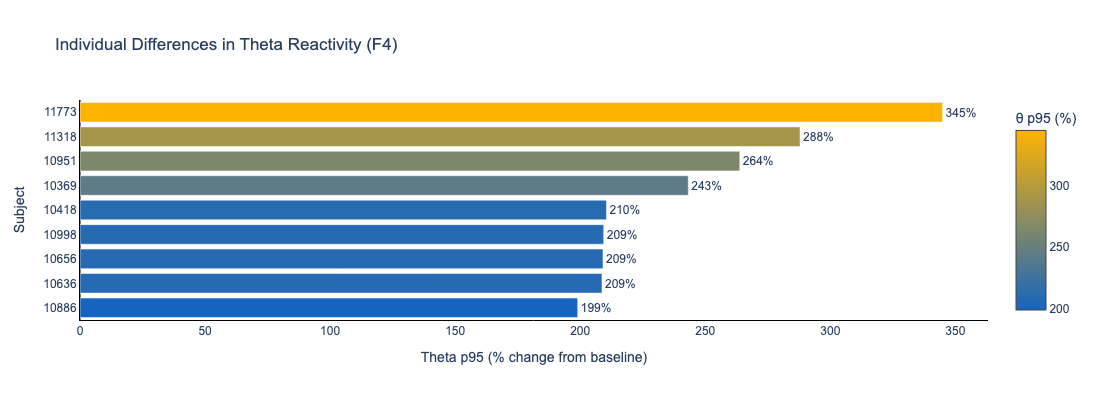

Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/feedback_theta/theta_reactivity_individual_differences.html


In [108]:
def plot_theta_reactivity_bar(clean_subject_avg):
    """
    Bar plot showing individual differences in theta reactivity.
    """
    df = clean_subject_avg.reset_index().sort_values('theta_p95', ascending=True)
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        y=df['subject_id'],
        x=df['theta_p95'],
        orientation='h',
        marker=dict(
            color=df['theta_p95'],
            colorscale=[[0, COLOR_BLUE], [1, COLOR_GOLD]],
            showscale=True,
            colorbar=dict(title='θ p95 (%)')
        ),
        text=df['theta_p95'].round(0).astype(int).astype(str) + '%',
        textposition='outside'
    ))
    
    fig.update_layout(
        title='Individual Differences in Theta Reactivity (F4)',
        xaxis_title='Theta p95 (% change from baseline)',
        yaxis_title='Subject',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        height=400,
        showlegend=False
    )
    
    fig.update_xaxes(showgrid=False, zeroline=True, zerolinecolor='gray', linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig


fig_bar = plot_theta_reactivity_bar(clean_subject_avg)
fig_bar.write_html(OUTPUT_DIR / 'theta_reactivity_individual_differences.html')
print(f"Saved: {OUTPUT_DIR / 'theta_reactivity_individual_differences.html'}")

---
## 11. Test-Retest Reliability

=== Test-Retest Reliability: Run 1 vs Run 5 ===
Subjects with both baseline runs: 6
Subjects: ['10886', '11773', '10656', '10418', '10636', '11318']

theta_p75: Pearson r = 0.861, p = 0.028, ICC ≈ 0.855
theta_p95: Pearson r = 0.667, p = 0.148, ICC ≈ 0.621
theta_p99: Pearson r = 0.865, p = 0.026, ICC ≈ 0.800


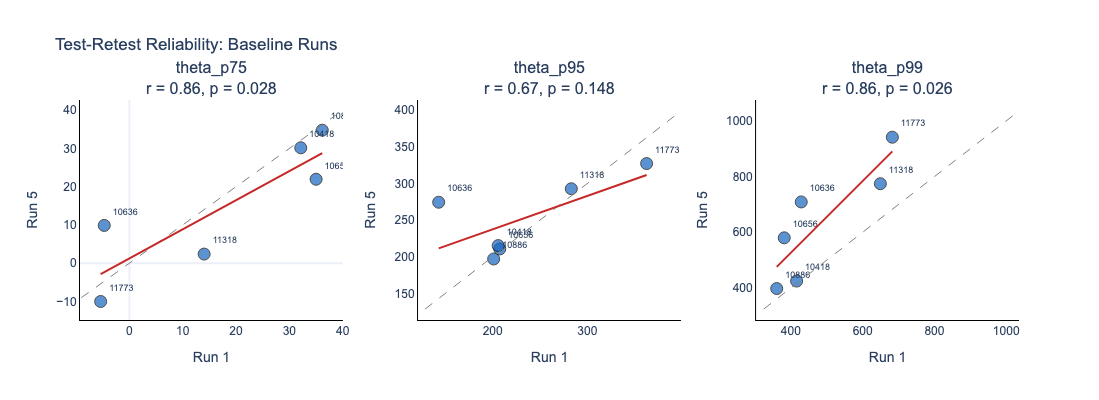


INTERPRETATION
ICC: <0.40=Poor, 0.40-0.59=Fair, 0.60-0.74=Good, 0.75-1.00=Excellent

Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/feedback_theta/theta_reliability_run1_vs_run5.html


In [113]:
def compute_run_reliability(df):
    """
    Correlate theta metrics between Run 1 and Run 5.
    """
    run1 = df[df['run'] == 1].set_index('subject_id')
    run5 = df[df['run'] == 5].set_index('subject_id')
    
    common_subs = run1.index.intersection(run5.index)
    
    print(f"=== Test-Retest Reliability: Run 1 vs Run 5 ===")
    print(f"Subjects with both baseline runs: {len(common_subs)}")
    print(f"Subjects: {list(common_subs)}\n")
    
    if len(common_subs) < 3:
        print("Too few subjects for reliability analysis")
        return None, None
    
    metrics = ['theta_p75', 'theta_p95', 'theta_p99']
    reliability_results = []
    
    for metric in metrics:
        r1_vals = run1.loc[common_subs, metric].values
        r5_vals = run5.loc[common_subs, metric].values
        
        r, p = pearsonr(r1_vals, r5_vals)
        
        subject_means = (r1_vals + r5_vals) / 2
        ms_subjects = np.var(subject_means, ddof=1) * 2
        diffs = r1_vals - r5_vals
        ms_error = np.var(diffs, ddof=1) / 2
        icc = (ms_subjects - ms_error) / (ms_subjects + ms_error) if (ms_subjects + ms_error) > 0 else np.nan
        
        reliability_results.append({'metric': metric, 'r': r, 'p': p, 'ICC': icc, 'n': len(common_subs)})
        
        print(f"{metric}: Pearson r = {r:.3f}, p = {p:.3f}, ICC ≈ {icc:.3f}")
    
    # Create Plotly figure
    fig = make_subplots(rows=1, cols=3, subplot_titles=metrics, horizontal_spacing=0.08)
    
    for idx, metric in enumerate(metrics):
        r1_vals = run1.loc[common_subs, metric].values
        r5_vals = run5.loc[common_subs, metric].values
        r, p = pearsonr(r1_vals, r5_vals)
        
        fig.add_trace(go.Scatter(
            x=r1_vals, y=r5_vals, mode='markers+text',
            marker=dict(size=12, color=COLOR_BLUE, opacity=0.7, line=dict(width=1, color='black')),
            text=list(common_subs), textposition='top right', textfont=dict(size=9),
            showlegend=False
        ), row=1, col=idx+1)
        
        all_vals = np.concatenate([r1_vals, r5_vals])
        line_range = [all_vals.min() * 0.9, all_vals.max() * 1.1]
        fig.add_trace(go.Scatter(x=line_range, y=line_range, mode='lines',
                                  line=dict(dash='dash', color='gray', width=1), showlegend=False), row=1, col=idx+1)
        
        z = np.polyfit(r1_vals, r5_vals, 1)
        fig.add_trace(go.Scatter(x=np.sort(r1_vals), y=np.poly1d(z)(np.sort(r1_vals)), mode='lines',
                                  line=dict(color=COLOR_RED, width=2), showlegend=False), row=1, col=idx+1)
        
        fig.layout.annotations[idx].text = f'{metric}<br>r = {r:.2f}, p = {p:.3f}'
        fig.update_xaxes(title_text=f'Run 1', row=1, col=idx+1, showgrid=False, linecolor='black', linewidth=1)
        fig.update_yaxes(title_text=f'Run 5', row=1, col=idx+1, showgrid=False, linecolor='black', linewidth=1)
    
    fig.update_layout(title='Test-Retest Reliability: Baseline Runs', template=PLOTLY_TEMPLATE,
                      font=dict(family='Arial'), height=400, width=1000)
    fig.show()
    
    print("\n" + "="*60 + "\nINTERPRETATION\n" + "="*60)
    print("ICC: <0.40=Poor, 0.40-0.59=Fair, 0.60-0.74=Good, 0.75-1.00=Excellent")
    
    return pd.DataFrame(reliability_results), fig


reliability_df, fig_rel = compute_run_reliability(clean_runs)
if fig_rel:
    fig_rel.write_html(OUTPUT_DIR / 'theta_reliability_run1_vs_run5.html')
    print(f"\nSaved: {OUTPUT_DIR / 'theta_reliability_run1_vs_run5.html'}")

---
## 12. QC Visualization: Raw Theta Power with Epoch Windows

4-panel visualization showing:
1. Event markers (reward vs no-reward)
2. Raw EEG with artifact threshold
3. Continuous theta power (artifacts masked)
4. Zoomed view

HIGH THETA REACTIVITY SUBJECT (sub-11773)
Sub-11773 Run 1: 2.8% masked


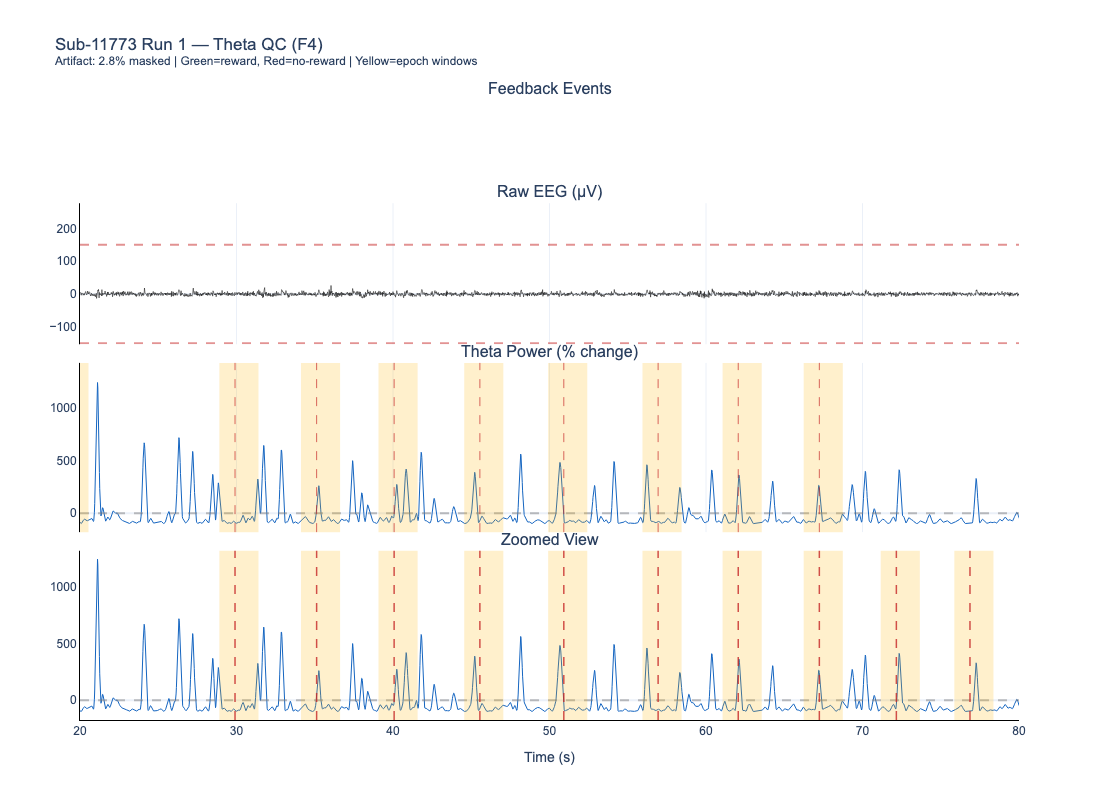


LOW THETA REACTIVITY SUBJECT (sub-10886)
Sub-10886 Run 1: 2.8% masked


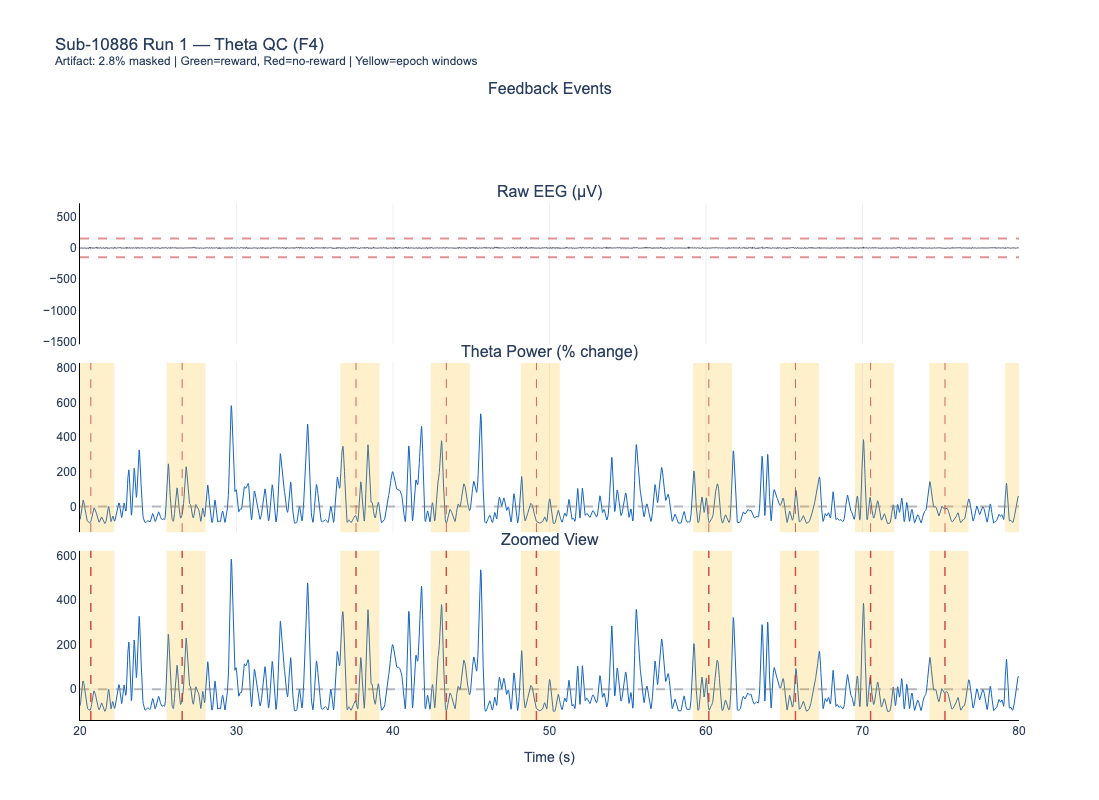

In [116]:
def plot_run_theta_qc(subject_id, run_num, channel_idx=0, 
                      artifact_thresh_uv=150, skip_first_sec=10):
    """
    Create 4-panel QC visualization of continuous theta power.
    """
    from scipy.signal import hilbert
    
    eeg_path = find_eeg_run(EEG_DIR, subject_id, run_num)
    if eeg_path is None:
        print(f"EEG file not found for sub-{subject_id} Run {run_num}")
        return None
    
    eeg_data = load_eeg_run(eeg_path)
    eeg_times = eeg_data['time_sec']
    
    behav_dir = BEHAV_DIR / f'sub-{subject_id}'
    behav_path = get_latest_run_file(behav_dir, run_num)
    if behav_path is None:
        print(f"Behavioral file not found")
        return None
    
    behav_df = load_behavioral_run(behav_path)
    sub_info = SUBJECT_INFO.get(subject_id, {})
    has_earclip = sub_info.get('earclip', False)
    eeg_data = preprocess_eeg(eeg_data, has_earclip=has_earclip)
    behav_df = align_timestamps(eeg_data, behav_df)
    feedback_times_eeg = behav_df['feedback_time_eeg']
    
    raw_signal = eeg_data['eeg'][:, channel_idx].copy()
    theta_filtered = bandpass_filter(raw_signal, THETA_BAND, FS)
    analytic_signal = hilbert(theta_filtered)
    theta_power = np.abs(analytic_signal) ** 2
    
    artifact_mask = np.abs(raw_signal) > artifact_thresh_uv
    startup_mask = eeg_times < skip_first_sec
    combined_mask = artifact_mask | startup_mask
    artifact_pct = 100 * combined_mask.sum() / len(combined_mask)
    
    window_samples = int(0.1 * FS)
    theta_power_smooth = np.convolve(theta_power, np.ones(window_samples)/window_samples, mode='same')
    theta_power_smooth_clean = theta_power_smooth.copy()
    theta_power_smooth_clean[combined_mask] = np.nan
    
    clean_mean = np.nanmean(theta_power_smooth_clean)
    theta_power_pct = (theta_power_smooth / clean_mean - 1) * 100
    theta_power_pct_clean = theta_power_pct.copy()
    theta_power_pct_clean[combined_mask] = np.nan
    
    print(f"Sub-{subject_id} Run {run_num}: {artifact_pct:.1f}% masked")
    
    # Downsample for plotting
    ds = 10
    times_ds = eeg_times[::ds]
    raw_ds = raw_signal[::ds]
    theta_ds = theta_power_pct_clean[::ds]
    
    # 4-panel figure
    fig = make_subplots(rows=4, cols=1, shared_xaxes=True,
                        row_heights=[0.15, 0.25, 0.30, 0.30],
                        vertical_spacing=0.03,
                        subplot_titles=['Feedback Events', 'Raw EEG (µV)', 
                                        'Theta Power (% change)', 'Zoomed View'])
    
    # Panel 1: Events
    for i, ft in enumerate(feedback_times_eeg):
        if ft > 0 and ft < eeg_times[-1]:
            reward_val = behav_df.iloc[i]['reward']
            is_reward = reward_val if isinstance(reward_val, bool) else str(reward_val).upper() == 'TRUE'
            fig.add_vline(x=ft, line_color=COLOR_GREEN if is_reward else COLOR_RED,
                          line_width=1, opacity=0.5, row=1, col=1)
    fig.add_vrect(x0=0, x1=skip_first_sec, fillcolor='gray', opacity=0.3, line_width=0, row=1, col=1)
    
    # Panel 2: Raw EEG
    fig.add_trace(go.Scatter(x=times_ds, y=raw_ds, mode='lines',
                              line=dict(color='black', width=0.5), showlegend=False), row=2, col=1)
    fig.add_hline(y=artifact_thresh_uv, line_dash='dash', line_color=COLOR_RED, opacity=0.5, row=2, col=1)
    fig.add_hline(y=-artifact_thresh_uv, line_dash='dash', line_color=COLOR_RED, opacity=0.5, row=2, col=1)
    
    # Panel 3: Full theta power
    fig.add_trace(go.Scatter(x=times_ds, y=theta_ds, mode='lines',
                              line=dict(color=COLOR_BLUE, width=1), showlegend=False), row=3, col=1)
    fig.add_hline(y=0, line_color='gray', line_dash='dash', opacity=0.5, row=3, col=1)
    
    # Add epoch windows
    epochs_shown = 0
    for ft in feedback_times_eeg:
        if ft - EPOCH_PRE > skip_first_sec and ft + EPOCH_POST < eeg_times[-1] and epochs_shown < 10:
            fig.add_vrect(x0=ft - EPOCH_PRE, x1=ft + EPOCH_POST,
                          fillcolor=COLOR_GOLD, opacity=0.2, line_width=0, row=3, col=1)
            fig.add_vline(x=ft, line_dash='dash', line_color=COLOR_RED, line_width=1, opacity=0.7, row=3, col=1)
            epochs_shown += 1
    
    # Panel 4: Zoomed view (60s window)
    zoom_start = skip_first_sec + 10
    zoom_end = zoom_start + 60
    zoom_mask = (times_ds >= zoom_start) & (times_ds <= zoom_end)
    
    fig.add_trace(go.Scatter(x=times_ds[zoom_mask], y=theta_ds[zoom_mask], mode='lines',
                              line=dict(color=COLOR_BLUE, width=1), showlegend=False), row=4, col=1)
    fig.add_hline(y=0, line_color='gray', line_dash='dash', opacity=0.5, row=4, col=1)
    
    for i, ft in enumerate(feedback_times_eeg):
        if zoom_start <= ft <= zoom_end:
            fig.add_vrect(x0=ft - EPOCH_PRE, x1=ft + EPOCH_POST,
                          fillcolor=COLOR_GOLD, opacity=0.2, line_width=0, row=4, col=1)
            fig.add_vline(x=ft, line_dash='dash', line_color=COLOR_RED, line_width=1.5, opacity=0.8, row=4, col=1)
    
    fig.update_xaxes(range=[zoom_start, zoom_end], row=4, col=1)
    
    ch_label = EEG_CH_LABELS[channel_idx]
    fig.update_layout(
        title=f'Sub-{subject_id} Run {run_num} — Theta QC ({ch_label})<br>'
              f'<sup>Artifact: {artifact_pct:.1f}% masked | Green=reward, Red=no-reward | Yellow=epoch windows</sup>',
        template=PLOTLY_TEMPLATE, font=dict(family='Arial'),
        height=800, width=1200, showlegend=False
    )
    
    fig.update_xaxes(title_text='Time (s)', row=4, col=1, showgrid=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig


# Plot QC for example subjects
print("=" * 70)
print("HIGH THETA REACTIVITY SUBJECT (sub-11773)")
print("=" * 70)
fig_high = plot_run_theta_qc('11773', 1)
if fig_high:
    fig_high.write_html(OUTPUT_DIR / 'theta_qc_sub11773_run1_high.html')

print("\n" + "=" * 70)
print("LOW THETA REACTIVITY SUBJECT (sub-10886)")
print("=" * 70)
fig_low = plot_run_theta_qc('10886', 1)
if fig_low:
    fig_low.write_html(OUTPUT_DIR / 'theta_qc_sub10886_run1_low.html')

---
## 13. Theta Reactivity vs Age

Examine whether theta reactivity varies with age.

=== Theta Reactivity vs Age ===
N = 9 subjects
Age range: 22 - 71 years
Pearson r = 0.025, p = 0.950
Spearman ρ = -0.259, p = 0.500


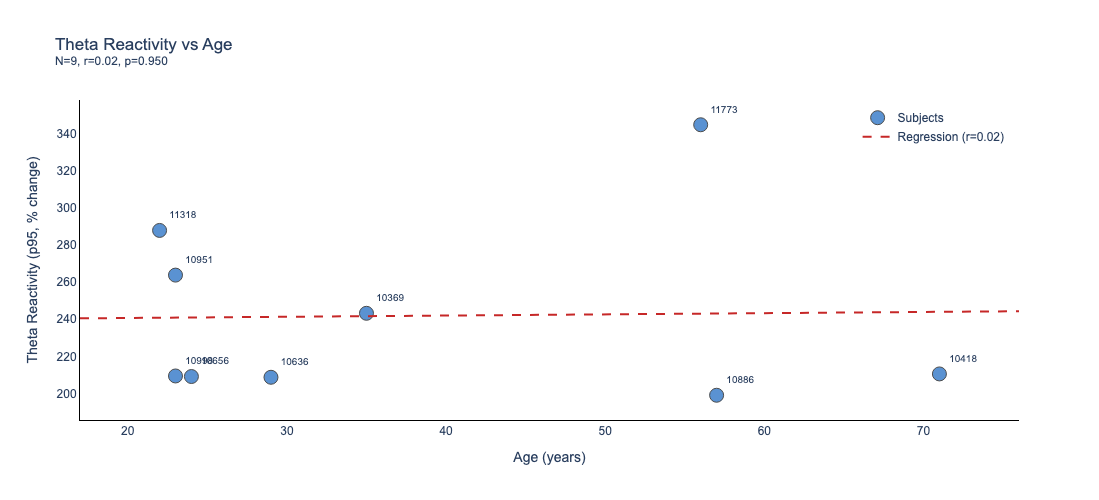


Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/feedback_theta/theta_reactivity_vs_age_scatter.html


In [118]:
def plot_theta_vs_age(clean_subject_avg):
    """
    Scatter plot of theta reactivity (p95) vs age.
    """
    df = clean_subject_avg.reset_index().dropna(subset=['age', 'theta_p95'])
    
    if len(df) < 3:
        print("Not enough subjects with age data")
        return None
    
    # Compute correlation
    r, p = pearsonr(df['age'], df['theta_p95'])
    rho, p_spearman = spearmanr(df['age'], df['theta_p95'])
    
    print(f"=== Theta Reactivity vs Age ===")
    print(f"N = {len(df)} subjects")
    print(f"Age range: {df['age'].min():.0f} - {df['age'].max():.0f} years")
    print(f"Pearson r = {r:.3f}, p = {p:.3f}")
    print(f"Spearman ρ = {rho:.3f}, p = {p_spearman:.3f}")
    
    # Create scatter plot
    fig = go.Figure()
    
    fig.add_trace(go.Scatter(
        x=df['age'],
        y=df['theta_p95'],
        mode='markers+text',
        marker=dict(size=14, color=COLOR_BLUE, opacity=0.7, line=dict(width=1, color='black')),
        text=df['subject_id'],
        textposition='top right',
        textfont=dict(size=10),
        name='Subjects'
    ))
    
    # Add regression line
    z = np.polyfit(df['age'], df['theta_p95'], 1)
    x_line = np.linspace(df['age'].min() - 5, df['age'].max() + 5, 100)
    fig.add_trace(go.Scatter(
        x=x_line,
        y=np.poly1d(z)(x_line),
        mode='lines',
        line=dict(color=COLOR_RED, width=2, dash='dash'),
        name=f'Regression (r={r:.2f})'
    ))
    
    fig.update_layout(
        title=f'Theta Reactivity vs Age<br><sup>N={len(df)}, r={r:.2f}, p={p:.3f}</sup>',
        xaxis_title='Age (years)',
        yaxis_title='Theta Reactivity (p95, % change)',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        legend=dict(yanchor='top', y=0.99, xanchor='right', x=0.99),
        height=500,
        width=700
    )
    
    fig.update_xaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, zeroline=False, linecolor='black', linewidth=1)
    
    fig.show()
    return fig, df


fig_age_scatter, age_df = plot_theta_vs_age(clean_subject_avg)
if fig_age_scatter:
    fig_age_scatter.write_html(OUTPUT_DIR / 'theta_reactivity_vs_age_scatter.html')
    print(f"\nSaved: {OUTPUT_DIR / 'theta_reactivity_vs_age_scatter.html'}")

### Young vs Old Comparison

=== Young vs Older Adults (cutoff: 55) ===
Young (<55): N=6, M=237.0%, SD=33.7%
Older (55+): N=3, M=251.5%, SD=81.1%
Independent t-test: t=-0.39, p=0.705


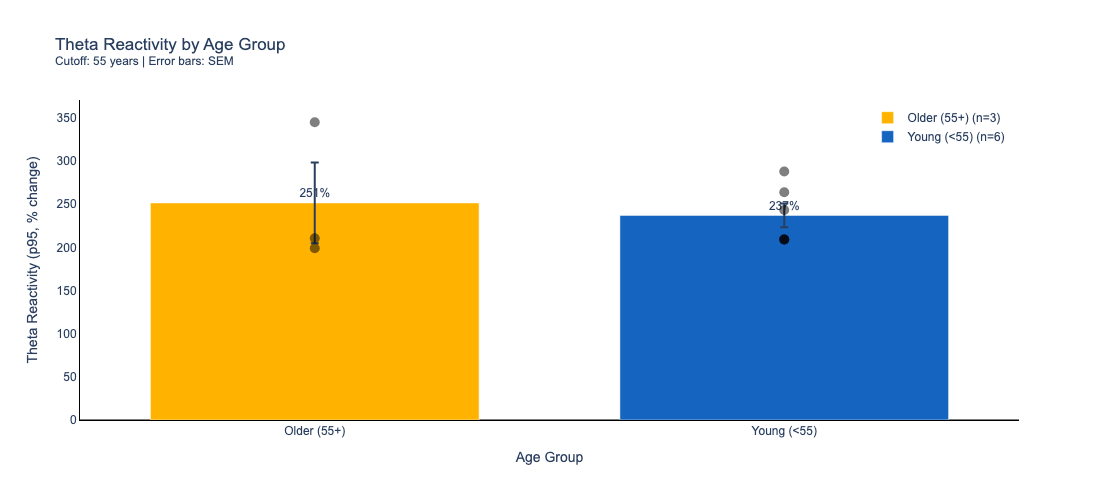


Saved: /Users/jameswyngaarden/Documents/GitHub/tacs_bandit/derivatives/eeg/feedback_theta/theta_reactivity_young_vs_old.html


In [125]:
def plot_young_vs_old(df, age_cutoff=55):
    """
    Compare theta reactivity between young (<55) and older (55+) adults.
    """
    if df is None or len(df) < 2:
        print("Not enough data")
        return None
    
    df = df.copy()
    df['age_group'] = df['age'].apply(lambda x: 'Young (<55)' if x < age_cutoff else 'Older (55+)')
    
    young = df[df['age_group'] == 'Young (<55)']['theta_p95']
    older = df[df['age_group'] == 'Older (55+)']['theta_p95']
    
    print(f"=== Young vs Older Adults (cutoff: {age_cutoff}) ===")
    print(f"Young (<{age_cutoff}): N={len(young)}, M={young.mean():.1f}%, SD={young.std():.1f}%")
    print(f"Older ({age_cutoff}+): N={len(older)}, M={older.mean():.1f}%, SD={older.std():.1f}%")
    
    if len(young) >= 2 and len(older) >= 2:
        t, p = ttest_ind(young, older)
        print(f"Independent t-test: t={t:.2f}, p={p:.3f}")
    else:
        print("Not enough subjects in each group for t-test")
    
    # Create grouped bar plot
    group_stats = df.groupby('age_group')['theta_p95'].agg(['mean', 'std', 'count']).reset_index()
    group_stats['sem'] = group_stats['std'] / np.sqrt(group_stats['count'])
    
    fig = go.Figure()
    
    colors = [COLOR_GOLD, COLOR_BLUE]
    
    for i, row in group_stats.iterrows():
        fig.add_trace(go.Bar(
            x=[row['age_group']],
            y=[row['mean']],
            error_y=dict(type='data', array=[row['sem']], visible=True),
            marker_color=colors[i],
            name=f"{row['age_group']} (n={int(row['count'])})",
            text=f"{row['mean']:.0f}%",
            textposition='outside'
        ))
    
    # Add individual points
    for i, grp in enumerate(['Young (<55)', 'Older (55+)']):
        grp_data = df[df['age_group'] == grp]
        fig.add_trace(go.Scatter(
            x=[grp] * len(grp_data),
            y=grp_data['theta_p95'],
            mode='markers',
            marker=dict(size=10, color='black', opacity=0.5),
            showlegend=False
        ))
    
    fig.update_layout(
        title=f'Theta Reactivity by Age Group<br><sup>Cutoff: {age_cutoff} years | Error bars: SEM</sup>',
        xaxis_title='Age Group',
        yaxis_title='Theta Reactivity (p95, % change)',
        template=PLOTLY_TEMPLATE,
        font=dict(family='Arial'),
        showlegend=True,
        legend=dict(yanchor='top', y=0.99, xanchor='right', x=0.99),
        height=500,
        width=500,
        bargap=0.3
    )
    
    fig.update_xaxes(showgrid=False, linecolor='black', linewidth=1)
    fig.update_yaxes(showgrid=False, zeroline=True, zerolinecolor='gray', linecolor='black', linewidth=1)
    
    fig.show()
    return fig


if age_df is not None:
    fig_age_groups = plot_young_vs_old(age_df, age_cutoff=55)
    if fig_age_groups:
        fig_age_groups.write_html(OUTPUT_DIR / 'theta_reactivity_young_vs_old.html')
        print(f"\nSaved: {OUTPUT_DIR / 'theta_reactivity_young_vs_old.html'}")

---
## 14. Notes and Limitations

### Methodological Notes

1. **Timestamp alignment**: Without hardware synchronization (LSL markers), we use heuristic alignment. Sensitivity analysis confirms individual differences are robust to ±1s alignment shifts (Spearman ρ > 0.90).

2. **Limited channels**: Only 3 EEG channels are available (F4, P4, P3); stimulation channels are blanked by NIC2.

3. **Reference electrode**: Subjects without earclip use software average re-reference across only 3 channels, which may attenuate signals.

4. **Theta band definition**: 4-8 Hz per standard conventions (Cohen, 2014; Cavanagh & Frank, 2014).

### Individual Differences Interpretation

The theta reactivity metric (p95) shows good-to-excellent test-retest reliability, supporting its use as a stable individual difference measure. This can be used to examine whether baseline theta reactivity moderates tACS effects on reward-based learning.

### References

- Cavanagh, J. F., & Frank, M. J. (2014). Frontal theta as a mechanism for cognitive control. *Trends in Cognitive Sciences, 18*(8), 414-421.
- Cohen, M. X. (2014). *Analyzing Neural Time Series Data: Theory and Practice*. MIT Press.
- Cicchetti, D. V. (1994). Guidelines, criteria, and rules of thumb for evaluating normed and standardized assessment instruments in psychology. *Psychological Assessment, 6*(4), 284-290.